# Complaint Sense — DistilBERT (CFPB Issue labels + API)

**Task:** Multi-class classification of consumer complaint narratives into **11 CFPB Issue** categories  
**Primary metric:** Macro F1

## Why this notebook

The full CFPB dump is **~8GB**. You do **not** need it.

**Recommended approach:**
1. Prefer a **local extract** (your Excel excerpt / any filtered CSV with narratives).
2. Else pull a **small balanced slice** from the [CFPB Search API](https://cfpb.github.io/api/ccdb/api.html) with `has_narrative=true` + `issue=...` (max `size=100` per page).
3. Train DistilBERT on `Consumer complaint narrative` → predict `Issue`.

Do **not** download the full zip unless you truly need every historical row.


## 1. Install / imports


In [19]:
# %pip install -q pandas numpy scikit-learn matplotlib seaborn torch transformers accelerate evaluate tqdm requests openpyxl


In [20]:
import json
import random
import re
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import requests
import seaborn as sns
import torch
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    EarlyStoppingCallback,
    Trainer,
    TrainingArguments,
    set_seed,
)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
set_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")


Device: cpu


## 2. Configuration — CFPB schema + exact Issue labels


In [21]:
# Resolve project root whether you run from Tri-ai/ or Tri-ai/scripts/
ROOT = Path(".").resolve()
if (ROOT / "scripts").exists() and not (ROOT / "data").exists():
    DATA_DIR = ROOT / "scripts" / "data"
    MODEL_DIR = ROOT / "scripts" / "models" / "distilbert-complaint-sense"
    OUTPUT_DIR = ROOT / "scripts" / "outputs"
elif (ROOT / "data").exists() or ROOT.name == "scripts":
    DATA_DIR = ROOT / "data"
    MODEL_DIR = ROOT / "models" / "distilbert-complaint-sense"
    OUTPUT_DIR = ROOT / "outputs"
else:
    DATA_DIR = ROOT / "data"
    MODEL_DIR = ROOT / "models" / "distilbert-complaint-sense"
    OUTPUT_DIR = ROOT / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Local sources (preferred over API when present)
# IMPORTANT: use the SMALL excerpt — NOT the full ~8GB complaints.csv dump
EXCERPT_XLSX = Path(r"C:\Users\HP\Downloads\excerpt from complaints_cfpb.xlsx")
# Full dump (DO NOT load with pandas.read_csv — will OOM):
# FULL_DUMP_CSV = Path(r"C:\Users\HP\Downloads\complaints.csv (1)\complaints.csv")
WORKING_CSV = DATA_DIR / "complaint_sense_working_cfpb.csv"
RAW_CSV = DATA_DIR / "cfpb_raw_with_narratives.csv"
MAX_LOCAL_LOAD_GB = 0.5  # refuse huge local files; use API instead
MAX_LOCAL_LOAD_GB = 0.5  # refuse loading local files larger than this; use API instead

# CFPB export / Excel column names
NARRATIVE_COL = "Consumer complaint narrative"
LABEL_COL = "Issue"
ID_COL = "Complaint ID"

# Exact Issue strings that return hits in the CFPB API
# NOTE: do NOT use "Trouble during the payment process" / "Struggling to pay the mortgage"
# (those return 0 hits). Use the strings below (no extra "the").
TARGET_ISSUES = [
    "Incorrect information on your report",
    "Improper use of your report",
    "Managing an account",
    "Problem with a company's investigation into an existing problem",
    "Problem with a purchase shown on your statement",
    "Attempts to collect debt not owed",
    "Trouble during payment process",
    "False statements or representation",
    "Struggling to pay mortgage",
    "Written notification about debt",
    "Took or threatened to take negative or legal action",
]

# Data loading strategy
DATA_SOURCE = "auto"  # "auto" | "local" | "api"
# auto: working CSV -> excerpt/xlsx/csv -> API
PER_CLASS_CAP = 30          # balanced modelling subset size per Issue
API_PAGE_SIZE = 100         # CFPB API max per request
API_MAX_PAGES_PER_ISSUE = 2 # safety cap (2*100=200 candidates / issue before balancing)
API_SLEEP_SEC = 0.35        # be polite to CFPB

MODEL_NAME = "distilbert-base-uncased"
MAX_LENGTH = 256
TEST_SIZE = 0.2
VAL_SIZE = 0.1
NUM_EPOCHS = 4
TRAIN_BATCH_SIZE = 8 if DEVICE == "cuda" else 4
EVAL_BATCH_SIZE = 16 if DEVICE == "cuda" else 8
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_STEPS = 50  # transformers 5.x uses warmup_steps (warmup_ratio removed)

CFPB_API = "https://www.consumerfinance.gov/data-research/consumer-complaints/search/api/v1/"

print("Paths:")
print("  working CSV:", WORKING_CSV)
print("  excerpt:    ", EXCERPT_XLSX, "| exists:", EXCERPT_XLSX.exists())
print("  model dir:  ", MODEL_DIR)
print("  outputs:    ", OUTPUT_DIR)
print(f"Issues: {len(TARGET_ISSUES)} | source={DATA_SOURCE} | per_class={PER_CLASS_CAP}")


Paths:
  working CSV: C:\Users\HP\Desktop\Tri-ai\scripts\data\complaint_sense_working_cfpb.csv
  excerpt:     C:\Users\HP\Downloads\excerpt from complaints_cfpb.xlsx | exists: True
  model dir:   C:\Users\HP\Desktop\Tri-ai\scripts\models\distilbert-complaint-sense
  outputs:     C:\Users\HP\Desktop\Tri-ai\scripts\outputs
Issues: 11 | source=auto | per_class=30


## 3. Load / build CFPB working set

Priority for `DATA_SOURCE="auto"`:
1. `data/complaints.csv` (already prepared)
2. Local Excel/CSV excerpt with narratives
3. CFPB API pull (filtered, not the 8GB dump)


In [22]:
def clean_narrative(text: str) -> str:
    if not isinstance(text, str):
        return ""
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    return text


def normalize_issue(value) -> str:
    """API sometimes returns issue as list / 'Issue•Sub-issue'."""
    if isinstance(value, list):
        value = value[0] if value else ""
    value = str(value or "").strip()
    if "•" in value:
        value = value.split("•", 1)[0].strip()
    return value


def standardize_frame(df: pd.DataFrame) -> pd.DataFrame:
    rename = {
        "complaint_id": ID_COL,
        "ComplaintId": ID_COL,
        "complaint_what_happened": NARRATIVE_COL,
        "consumer_complaint_narrative": NARRATIVE_COL,
        "narrative": NARRATIVE_COL,
        "text": NARRATIVE_COL,
        "issue": LABEL_COL,
        "Category": LABEL_COL,
    }
    out = df.rename(columns={k: v for k, v in rename.items() if k in df.columns}).copy()
    if LABEL_COL in out.columns:
        out[LABEL_COL] = out[LABEL_COL].map(normalize_issue)
    if NARRATIVE_COL in out.columns:
        out[NARRATIVE_COL] = out[NARRATIVE_COL].map(clean_narrative)
    return out


def filter_and_balance(df: pd.DataFrame, per_class: int = PER_CLASS_CAP) -> pd.DataFrame:
    required = [NARRATIVE_COL, LABEL_COL]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise KeyError(f"Missing columns {missing}. Available: {df.columns.tolist()}")

    work = df.copy()
    work = work[work[NARRATIVE_COL].str.len() > 20]
    work = work[~work[NARRATIVE_COL].isin(["", "nan", "None"])]
    work = work[work[LABEL_COL].isin(TARGET_ISSUES)].copy()
    before = len(work)
    work = work.drop_duplicates(subset=[NARRATIVE_COL], keep="first")
    print(f"Filtered: {before:,} -> {len(work):,} unique narratives in target Issues")

    parts = []
    print("\nSamples per Issue:")
    for issue in TARGET_ISSUES:
        subset = work[work[LABEL_COL] == issue]
        n = min(per_class, len(subset))
        if n == 0:
            print(f"  WARNING: 0 samples for '{issue}'")
            continue
        parts.append(subset.sample(n=n, random_state=SEED))
        print(f"  {issue[:55]:<55} -> {n}")

    if not parts:
        raise ValueError("No rows matched TARGET_ISSUES after filtering.")

    balanced = pd.concat(parts, ignore_index=True)
    balanced = balanced.sample(frac=1.0, random_state=SEED).reset_index(drop=True)

    keep = [c for c in [
        ID_COL, NARRATIVE_COL, LABEL_COL, "Product", "Sub-product", "Sub-issue",
        "Company", "Date received", "State", "ZIP code",
        "Company response to consumer", "Submitted via",
    ] if c in balanced.columns]
    return balanced[keep]


def fetch_issue_from_api(issue: str, need: int) -> list[dict]:
    """Paginate CFPB search API for one Issue with narratives."""
    rows = []
    frm = 0
    pages = 0
    while len(rows) < need and pages < API_MAX_PAGES_PER_ISSUE:
        params = {
            "has_narrative": "true",
            "size": API_PAGE_SIZE,
            "frm": frm,
            "issue": issue,
            "no_aggs": "true",
            "sort": "created_date_desc",
        }
        resp = requests.get(CFPB_API, params=params, timeout=90)
        resp.raise_for_status()
        payload = resp.json()
        hits = payload.get("hits", {}).get("hits", [])
        if not hits:
            break
        for hit in hits:
            src = hit.get("_source", {})
            narr = src.get("complaint_what_happened") or ""
            if not narr or len(str(narr).strip()) <= 20:
                continue
            issue_norm = normalize_issue(src.get("issue"))
            if issue_norm != issue:
                continue
            rows.append({
                ID_COL: src.get("complaint_id"),
                NARRATIVE_COL: narr,
                LABEL_COL: issue_norm,
                "Product": src.get("product"),
                "Sub-product": src.get("sub_product"),
                "Sub-issue": src.get("sub_issue"),
                "Company": src.get("company"),
                "Date received": src.get("date_received"),
                "State": src.get("state"),
                "ZIP code": src.get("zip_code"),
                "Company response to consumer": src.get("company_response"),
                "Submitted via": src.get("submitted_via"),
            })
        pages += 1
        frm += API_PAGE_SIZE
        time.sleep(API_SLEEP_SEC)
    return rows


def build_from_api(per_class: int = PER_CLASS_CAP) -> pd.DataFrame:
    print("Fetching from CFPB API (narratives only, per Issue)...")
    print(f"Endpoint: {CFPB_API}")
    need = max(per_class * 3, per_class + 10)
    all_rows = []
    for issue in TARGET_ISSUES:
        got = fetch_issue_from_api(issue, need=need)
        print(f"  {issue[:55]:<55} fetched {len(got)}")
        all_rows.extend(got)
    raw = pd.DataFrame(all_rows)
    raw_path = DATA_DIR / "cfpb_api_raw_cache.csv"
    raw.to_csv(raw_path, index=False)
    print(f"Cached API raw -> {raw_path} ({len(raw)} rows)")
    return filter_and_balance(standardize_frame(raw), per_class=per_class)


def load_local_table(path: Path) -> pd.DataFrame:
    size_gb = path.stat().st_size / (1024 ** 3)
    print(f"Opening {path} ({size_gb:.2f} GB)")
    if size_gb > MAX_LOCAL_LOAD_GB:
        raise MemoryError(
            f"Refusing to load {path.name} ({size_gb:.2f} GB). "
            f"Limit is {MAX_LOCAL_LOAD_GB} GB.\n"
            "Do NOT point EXCERPT_XLSX at the full complaints.csv dump.\n"
            "Use the small Excel excerpt, or set DATA_SOURCE='api'."
        )
    suffix = path.suffix.lower()
    if suffix in {".xlsx", ".xls"}:
        return pd.read_excel(path)
    if suffix == ".csv":
        return pd.read_csv(path, low_memory=False)
    raise ValueError(f"Unsupported file type: {suffix} ({path})")


# ---------------- load ----------------
df = None

if DATA_SOURCE in {"auto", "local"} and WORKING_CSV.exists():
    df = standardize_frame(pd.read_csv(WORKING_CSV))
    print(f"Loaded working CSV: {WORKING_CSV} ({len(df)} rows)")
elif DATA_SOURCE in {"auto", "local"} and EXCERPT_XLSX.exists():
    raw = standardize_frame(load_local_table(EXCERPT_XLSX))
    print(f"Loaded excerpt: {EXCERPT_XLSX} ({len(raw)} rows)")
    try:
        df = filter_and_balance(raw, per_class=PER_CLASS_CAP)
        if len(df) < max(50, len(TARGET_ISSUES) * 5) and DATA_SOURCE == "auto":
            print(f"Excerpt too small for training ({len(df)} rows) — falling back to API.")
            df = None
    except Exception as e:
        print(f"Excerpt not usable alone ({e}) — falling back to API." if DATA_SOURCE == "auto" else "")
        if DATA_SOURCE == "local":
            raise
        df = None
elif DATA_SOURCE in {"auto", "local"} and RAW_CSV.exists():
    raw = standardize_frame(load_local_table(RAW_CSV))
    print(f"Loaded raw CSV: {RAW_CSV} ({len(raw)} rows)")
    df = filter_and_balance(raw, per_class=PER_CLASS_CAP)

if df is None:
    if DATA_SOURCE == "local":
        raise FileNotFoundError(
            "DATA_SOURCE='local' but no usable local file found.\n"
            f"Tried: {WORKING_CSV}, {EXCERPT_XLSX}, {RAW_CSV}"
        )
    df = build_from_api(per_class=PER_CLASS_CAP)

df = standardize_frame(df)
df = df[df[NARRATIVE_COL].str.len() > 20].copy()
df = df[df[LABEL_COL].isin(TARGET_ISSUES)].copy().reset_index(drop=True)
df.to_csv(WORKING_CSV, index=False)

print("\nFinal working set:", df.shape)
print(df[LABEL_COL].value_counts().reindex(TARGET_ISSUES).fillna(0).astype(int))
print(f"Saved -> {WORKING_CSV}")
display(df.head(3))


Loaded working CSV: C:\Users\HP\Desktop\Tri-ai\scripts\data\complaint_sense_working_cfpb.csv (330 rows)

Final working set: (330, 12)
Issue
Incorrect information on your report                               30
Improper use of your report                                        30
Managing an account                                                30
Problem with a company's investigation into an existing problem    30
Problem with a purchase shown on your statement                    30
Attempts to collect debt not owed                                  30
Trouble during payment process                                     30
False statements or representation                                 30
Struggling to pay mortgage                                         30
Written notification about debt                                    30
Took or threatened to take negative or legal action                30
Name: count, dtype: int64
Saved -> C:\Users\HP\Desktop\Tri-ai\scripts\data\complaint_sense

,Complaint ID,Consumer complaint narrative,Issue,Product,Sub-product,Sub-issue,Company,Date received,State,ZIP code,Company response to consumer,Submitted via
0,24228388,I am submitting this complaint because TransUn...,Incorrect information on your report,Vehicle loan or lease,Loan,Account status incorrect,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2026-07-15T16:57:05.000Z,FL,33409,Closed with non-monetary relief,Web
1,24662117,I am not liable for this debt with these follo...,Attempts to collect debt not owed,Debt collection,Other debt,Debt is not yours,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",2026-07-28T02:47:45.000Z,MS,39110,Closed with non-monetary relief,Web
2,24622801,I went shopping at Macys & gave them my Macys ...,Problem with a purchase shown on your statement,Credit card,General-purpose credit card or charge card,Card was charged for something you did not pur...,"CITIBANK, N.A.",2026-07-27T02:10:18.000Z,CA,94015,Closed with monetary relief,Web


## 4. Exploratory checks


Exact duplicate narratives remaining: 0


,count
Issue,
Incorrect information on your report,30
Improper use of your report,30
Managing an account,30
Problem with a company's investigation into an existing problem,30
Problem with a purchase shown on your statement,30
Attempts to collect debt not owed,30
Trouble during payment process,30
False statements or representation,30
Struggling to pay mortgage,30


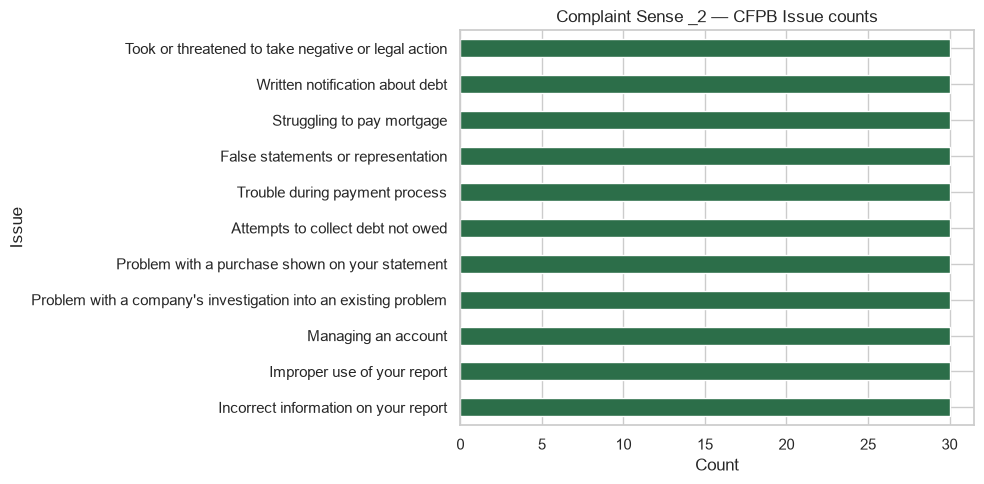

count     330.0
mean      249.1
std       208.5
min         8.0
25%        97.2
50%       200.0
75%       343.2
max      1420.0
Name: narrative_len, dtype: float64

In [23]:
dup_n = df.duplicated(subset=[NARRATIVE_COL]).sum()
print(f"Exact duplicate narratives remaining: {dup_n}")
if dup_n:
    df = df.drop_duplicates(subset=[NARRATIVE_COL], keep="first").reset_index(drop=True)

class_counts = df[LABEL_COL].value_counts().reindex(TARGET_ISSUES).fillna(0).astype(int)
display(class_counts.to_frame("count"))

fig, ax = plt.subplots(figsize=(10, 5))
class_counts.plot(kind="barh", ax=ax, color="#2c6e49")
ax.set_xlabel("Count")
ax.set_title("Complaint Sense _2 — CFPB Issue counts")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

df["narrative_len"] = df[NARRATIVE_COL].str.split().str.len()
display(df["narrative_len"].describe().round(1))


## 5. Labels, splits, tokenization


In [24]:
label2id = {label: i for i, label in enumerate(TARGET_ISSUES)}
id2label = {i: label for label, i in label2id.items()}
df["label_id"] = df[LABEL_COL].map(label2id)
assert df["label_id"].notna().all(), "Found labels outside TARGET_ISSUES"

train_df, test_df = train_test_split(
    df, test_size=TEST_SIZE, random_state=SEED, stratify=df["label_id"]
)
train_df, val_df = train_test_split(
    train_df, test_size=VAL_SIZE, random_state=SEED, stratify=train_df["label_id"]
)
train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")
print(train_df[LABEL_COL].value_counts().reindex(TARGET_ISSUES).fillna(0).astype(int))

train_df.to_csv(OUTPUT_DIR / "train.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test.csv", index=False)
with open(OUTPUT_DIR / "label_map.json", "w", encoding="utf-8") as f:
    json.dump({"label2id": label2id, "id2label": {str(k): v for k, v in id2label.items()}}, f, indent=2)


Train: 237 | Val: 27 | Test: 66
Issue
Incorrect information on your report                               22
Improper use of your report                                        22
Managing an account                                                22
Problem with a company's investigation into an existing problem    21
Problem with a purchase shown on your statement                    21
Attempts to collect debt not owed                                  22
Trouble during payment process                                     21
False statements or representation                                 21
Struggling to pay mortgage                                         21
Written notification about debt                                    22
Took or threatened to take negative or legal action                22
Name: count, dtype: int64


In [25]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ComplaintDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length=MAX_LENGTH):
        self.texts = list(texts)
        self.labels = list(labels)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt",
        )
        item = {k: v.squeeze(0) for k, v in enc.items()}
        item["labels"] = torch.tensor(int(self.labels[idx]), dtype=torch.long)
        return item


train_ds = ComplaintDataset(train_df[NARRATIVE_COL], train_df["label_id"], tokenizer)
val_ds = ComplaintDataset(val_df[NARRATIVE_COL], val_df["label_id"], tokenizer)
test_ds = ComplaintDataset(test_df[NARRATIVE_COL], test_df["label_id"], tokenizer)
print("example keys:", {k: tuple(v.shape) if hasattr(v, "shape") else v for k, v in train_ds[0].items()})


example keys: {'input_ids': (256,), 'token_type_ids': (256,), 'attention_mask': (256,), 'labels': ()}


## 6. Fine-tune DistilBERT


In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(TARGET_ISSUES),
    id2label=id2label,
    label2id=label2id,
)


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="macro", zero_division=0
    )
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1,
        "weighted_f1": f1_score(labels, preds, average="weighted", zero_division=0),
        "macro_precision": precision,
        "macro_recall": recall,
    }


training_args = TrainingArguments(
    output_dir=str(MODEL_DIR / "checkpoints"),
    num_train_epochs=NUM_EPOCHS,
    per_device_train_batch_size=TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=EVAL_BATCH_SIZE,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=WARMUP_STEPS,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_strategy="epoch",
    report_to="none",
    seed=SEED,
    fp16=torch.cuda.is_available(),
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Starting fine-tune...")
train_result = trainer.train()
print(train_result.metrics)


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 3857.15it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Starting fine-tune...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1,2.393984,2.378243,0.148148,0.097403,0.089947,0.083333,0.166667
2,2.313644,2.262348,0.222222,0.123776,0.117949,0.087879,0.227273
3,2.097442,2.090511,0.259259,0.198505,0.181946,0.191667,0.272727
4,1.934663,2.046032,0.296296,0.212646,0.193469,0.174351,0.318182


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.78it/s]


{'train_runtime': 1173.1005, 'train_samples_per_second': 0.808, 'train_steps_per_second': 0.205, 'total_flos': 62799624824832.0, 'train_loss': 2.1849332491556805, 'epoch': 4.0}


In [27]:
trainer.save_model(str(MODEL_DIR))
tokenizer.save_pretrained(str(MODEL_DIR))
print(f"Saved model -> {MODEL_DIR}")
val_metrics = trainer.evaluate()
print("Validation:")
for k, v in val_metrics.items():
    print(f"  {k}: {v:.4f}" if isinstance(v, float) else f"  {k}: {v}")


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.81it/s]


Saved model -> C:\Users\HP\Desktop\Tri-ai\scripts\models\distilbert-complaint-sense


Training Loss,Validation Loss,Epoch,Accuracy,Macro F1,Weighted F1,Macro Precision,Macro Recall
1.934663,2.046032,4,0.296296,0.212646,0.193469,0.174351,0.318182


Validation:
  eval_loss: 2.0460
  eval_accuracy: 0.2963
  eval_macro_f1: 0.2126
  eval_weighted_f1: 0.1935
  eval_macro_precision: 0.1744
  eval_macro_recall: 0.3182


## 7. Evaluate (Macro F1 + per-class)


In [28]:
pred_output = trainer.predict(test_ds)
y_true = pred_output.label_ids
y_pred = np.argmax(pred_output.predictions, axis=-1)

macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)
acc = accuracy_score(y_true, y_pred)

print("=== Held-out test ===")
print(f"Accuracy   : {acc:.4f}")
print(f"Macro F1   : {macro_f1:.4f}  <-- primary")
print(f"Weighted F1: {weighted_f1:.4f}\n")

short_names = [lbl if len(lbl) <= 42 else lbl[:39] + "..." for lbl in TARGET_ISSUES]
print(classification_report(y_true, y_pred, target_names=short_names, digits=3, zero_division=0))

report_dict = classification_report(
    y_true, y_pred, target_names=TARGET_ISSUES, output_dict=True, zero_division=0
)
per_class = (
    pd.DataFrame(report_dict)
    .T.loc[TARGET_ISSUES, ["precision", "recall", "f1-score", "support"]]
    .rename(columns={"f1-score": "f1"})
)
display(per_class.round(3))

summary = {
    "accuracy": float(acc),
    "macro_f1": float(macro_f1),
    "weighted_f1": float(weighted_f1),
    "n_test": int(len(y_true)),
    "model": MODEL_NAME,
    "labels": TARGET_ISSUES,
}
with open(OUTPUT_DIR / "test_metrics.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2)
per_class.to_csv(OUTPUT_DIR / "per_class_metrics.csv")


=== Held-out test ===
Accuracy   : 0.3182
Macro F1   : 0.2640  <-- primary
Weighted F1: 0.2640

                                            precision    recall  f1-score   support

      Incorrect information on your report      0.250     0.500     0.333         6
               Improper use of your report      0.333     0.167     0.222         6
                       Managing an account      0.385     0.833     0.526         6
Problem with a company's investigation ...      0.000     0.000     0.000         6
Problem with a purchase shown on your s...      0.800     0.667     0.727         6
         Attempts to collect debt not owed      0.250     0.167     0.200         6
            Trouble during payment process      0.333     0.667     0.444         6
        False statements or representation      0.000     0.000     0.000         6
                Struggling to pay mortgage      0.000     0.000     0.000         6
           Written notification about debt      0.200     0.333

,precision,recall,f1,support
Incorrect information on your report,0.250,0.500,0.333,6.0
Improper use of your report,0.333,0.167,0.222,6.0
Managing an account,0.385,0.833,0.526,6.0
Problem with a company's investigation into an existing problem,0.000,0.000,0.000,6.0
Problem with a purchase shown on your statement,0.800,0.667,0.727,6.0
Attempts to collect debt not owed,0.250,0.167,0.200,6.0
Trouble during payment process,0.333,0.667,0.444,6.0
False statements or representation,0.000,0.000,0.000,6.0
Struggling to pay mortgage,0.000,0.000,0.000,6.0
Written notification about debt,0.200,0.333,0.250,6.0


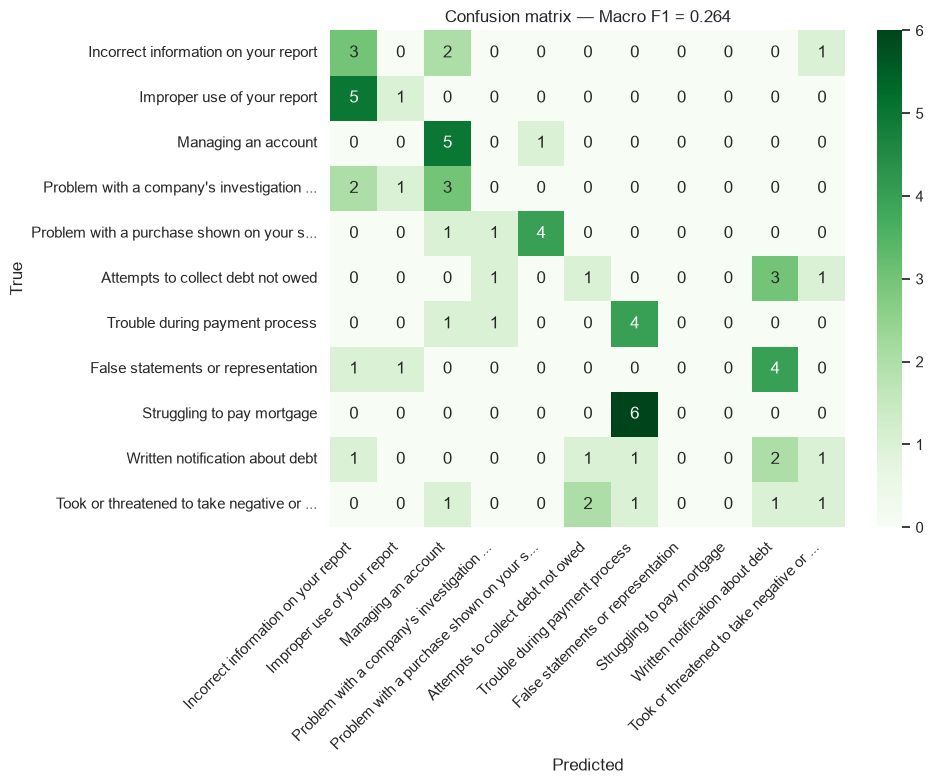

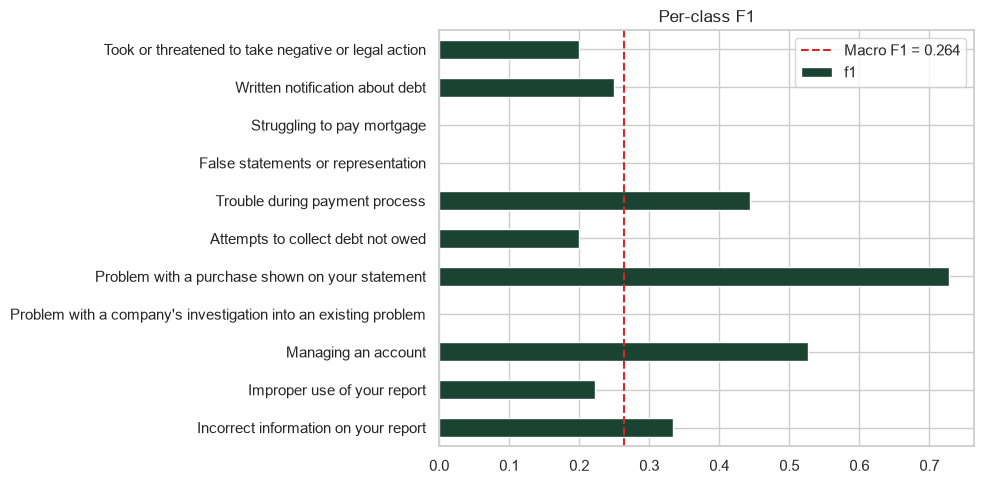

In [29]:
cm = confusion_matrix(y_true, y_pred, labels=list(range(len(TARGET_ISSUES))))
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=short_names, yticklabels=short_names, ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title(f"Confusion matrix — Macro F1 = {macro_f1:.3f}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
per_class["f1"].plot(kind="barh", ax=ax, color="#1b4332")
ax.axvline(macro_f1, color="#d62828", linestyle="--", label=f"Macro F1 = {macro_f1:.3f}")
ax.set_title("Per-class F1")
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUT_DIR / "per_class_f1.png", dpi=150, bbox_inches="tight")
plt.show()


## 8. Inference helper


In [30]:
def predict_complaint(text: str, top_k: int = 3):
    model.eval()
    enc = tokenizer(
        clean_narrative(text),
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH,
        return_tensors="pt",
    )
    enc = {k: v.to(model.device) for k, v in enc.items()}
    with torch.no_grad():
        probs = torch.softmax(model(**enc).logits.squeeze(0), dim=-1).cpu().numpy()
    order = np.argsort(probs)[::-1][:top_k]
    return [(id2label[i], float(probs[i])) for i in order]


demo = (
    "I keep seeing accounts on my credit report that do not belong to me. "
    "I disputed the information but the wrong balances are still showing."
)
print("Demo:", demo, "\n")
for label, score in predict_complaint(demo):
    print(f"  {score:.3f}  {label}")


Demo: I keep seeing accounts on my credit report that do not belong to me. I disputed the information but the wrong balances are still showing. 

  0.147  Incorrect information on your report
  0.130  Attempts to collect debt not owed
  0.127  Took or threatened to take negative or legal action


## 9. Notes / data-card alignment

| Item | Value |
|------|--------|
| Source | CFPB Consumer Complaint Database (API or filtered export) |
| Labels | `Issue` (11 selected categories) |
| Text | `Consumer complaint narrative` |
| Avoid | Full ~8GB dump; wrong label strings with extra "the" |
| Primary metric | Macro F1 |
